# Modelo IAN-R1 TRIGA

In [1]:
%matplotlib inline
import numpy as np
import openmc

In [2]:
#Materiales

#Moderador (agua)
water = openmc.Material(name='Light Water')
water.set_density('g/cm3', 0.997)
water.add_element('H', 2.0, 'ao')
water.add_element('O', 1.0, 'ao')
water.add_s_alpha_beta('c_H_in_H2O')

#Combustible
uzrh = openmc.Material(name='UZrH')
uzrh.set_density('g/cm3', 5.9725)
uzrh.add_nuclide('U235', 0.02518, 'wo')
uzrh.add_nuclide('U238', 0.10232, 'wo')
uzrh.add_element('H', 0.0150, 'wo')
uzrh.add_element('Zr', 0.8575, 'wo')


#Tablas termalizacion
uzrh.add_s_alpha_beta('c_H_in_ZrH')
uzrh.add_s_alpha_beta('c_Zr_in_ZrH')

molybdenum = openmc.Material(name='Molybdenum')
molybdenum.add_element('Mo', 1.0)
molybdenum.set_density('g/cm3', 10.22)

#Reflector
graphite = openmc.Material(name='Graphite')
graphite.set_density('g/cm3', 1.70)
graphite.add_element('C', 1.0)
graphite.add_s_alpha_beta('c_Graphite')

#Acero inoxidable
ss304 = openmc.Material(name='Stainless Steel 304')
ss304.set_density('g/cm3', 8.0)
ss304.add_element('C',.002,'wo')
ss304.add_element('Si',.004,'wo')
ss304.add_element('P',.0003,'wo')
ss304.add_element('S',.0002,'wo')
ss304.add_element('V',.003,'wo')
ss304.add_element('Cr',.115,'wo')
ss304.add_element('Mn',.006,'wo')
ss304.add_element('Fe',.8495,'wo')
ss304.add_element('Ni',.005,'wo')
ss304.add_element('Mo',.01,'wo')
ss304.add_element('W',.005,'wo')

#Control
b4c = openmc.Material(name='Boron Carbide')
b4c.set_density('g/cm3', 2.52)
b4c.add_element('B', 4)
b4c.add_element('C', 1)

zirconium = openmc.Material(name='Zirconium')
zirconium.add_element('Zr', 1.0)
zirconium.set_density('g/cm3', 6.506)

#Aire-irradiacion
air = openmc.Material(name='Air')
air.set_density('g/cm3', 0.001205)
air.add_element('N', 0.755268, 'wo')
air.add_element('C', 0.000124, 'wo')
air.add_element('O', 0.231781, 'wo')
air.add_element('Ar', 0.012827, 'wo')

aluminum = openmc.Material(name='Aluminum')
aluminum.add_element('Al', 1.0)
aluminum.set_density('g/cm3', 2.6)


#vacio-estructura
void = openmc.Material(name='Void')
void.set_density('g/cm3', 0.001205)
void.add_element('N', 0.755268, 'wo')
void.add_element('C', 0.000124, 'wo')
void.add_element('O', 0.231781, 'wo')
void.add_element('Ar', 0.012827, 'wo')



#Exportar a XML
materials_file = openmc.Materials([aluminum, zirconium, b4c, ss304, graphite, molybdenum, uzrh, water, air, void])
materials_file.export_to_xml()

In [3]:
#Barras de Combustible

#Geometria-cilindros (cm)
rod_outer_radius = openmc.ZCylinder(r=0.3175)
uzrh_outer_radius = openmc.ZCylinder(r=1.690)
gap_outer_radius = openmc.ZCylinder(r=1.695) 
clad_outer_radius = openmc.ZCylinder(r=1.745) 
graphite_outer_radius = openmc.ZCylinder(r=1.690)

#Planos  (cm)
z_bot_clad = openmc.ZPlane(z0=-76.5)
z_bot_graph = openmc.ZPlane(z0=-64.621664)
z_bot_mo = openmc.ZPlane(z0=-55.15864)
z_bot_fuel = openmc.ZPlane(z0=-55.079265)
z_top_fuel = openmc.ZPlane(z0=-16.979265)
z_top_graph = openmc.ZPlane(z0=-10.375265)
z_top_clad = openmc.ZPlane(z0=0.0)

fuel_universe = openmc.Universe(name='UZrH Fuel Universe')

#Celdas
fuel_universe.add_cell(openmc.Cell(name='Zr Rod', fill=zirconium, region=-rod_outer_radius & +z_bot_fuel & -z_top_fuel))
fuel_universe.add_cell(openmc.Cell(name='UZrH', fill=uzrh, region=+rod_outer_radius & -uzrh_outer_radius & +z_bot_fuel & -z_top_fuel))
fuel_universe.add_cell(openmc.Cell(name='Structural Gap', fill=void, region=+uzrh_outer_radius & -gap_outer_radius & +z_bot_fuel & -z_top_fuel))
fuel_universe.add_cell(openmc.Cell(name='Molybdenum', fill=molybdenum, region=-gap_outer_radius & +z_bot_mo & -z_bot_fuel))
fuel_universe.add_cell(openmc.Cell(name='Lower Graphite', fill=graphite, region=-gap_outer_radius & +z_bot_graph & -z_bot_mo))
fuel_universe.add_cell(openmc.Cell(name='Upper Graphite', fill=graphite, region=-gap_outer_radius & +z_top_fuel & -z_top_graph))
fuel_universe.add_cell(openmc.Cell(name='Lower Graphite Gap', fill=void, region=+graphite_outer_radius & -gap_outer_radius & +z_bot_graph & -z_bot_mo))
fuel_universe.add_cell(openmc.Cell(name='Upper Graphite Gap', fill=void, region=+graphite_outer_radius & -gap_outer_radius & +z_top_fuel & -z_top_graph))
fuel_universe.add_cell(openmc.Cell(name='Lower SS304', fill=ss304, region=-gap_outer_radius & +z_bot_clad & -z_bot_graph))
fuel_universe.add_cell(openmc.Cell(name='Upper SS304', fill=ss304, region=-gap_outer_radius & +z_top_graph & -z_top_clad))

#Revestimiento
fuel_universe.add_cell(openmc.Cell(name='Cladding', fill=ss304, region=-clad_outer_radius & +gap_outer_radius & +z_bot_clad & -z_top_clad))

#Sellos de agua 
fuel_universe.add_cell(openmc.Cell(name='Water Below', fill=water, region=-clad_outer_radius & -z_bot_clad))
fuel_universe.add_cell(openmc.Cell(name='Water Above', fill=water, region=-clad_outer_radius & +z_top_clad))
fuel_universe.add_cell(openmc.Cell(name='Water Background', fill=water, region=+clad_outer_radius))

In [4]:
#Barras de Control

#Geometria-cilindros
rod_outer_radius = openmc.ZCylinder(r=0.3175)
uzrh_outer_radius = openmc.ZCylinder(r=1.695)
clad_outer_radius = openmc.ZCylinder(r=1.745)

z_ext = 0 #Altura de extraccion

#Planos
z_bot = openmc.ZPlane(z0=-114.3 + z_ext)
z_ss5_top = openmc.ZPlane(z0=-113.03 + z_ext)
z_ss4_bot = openmc.ZPlane(z0=-99.06 + z_ext)
z_fuel_bot = openmc.ZPlane(z0=-96.52 + z_ext)
z_fuel_top = openmc.ZPlane(z0=-58.42 + z_ext)
z_ss1_bot = openmc.ZPlane(z0=-57.785 + z_ext)
z_b4c_bot = openmc.ZPlane(z0=-56.515 + z_ext)
z_b4c_top = openmc.ZPlane(z0=-18.415 + z_ext)
z_ss2_bot = openmc.ZPlane(z0=-18.0975 + z_ext)
z_ss2_top = openmc.ZPlane(z0=-16.8275 + z_ext)
z_ss3_bot = openmc.ZPlane(z0=-7.3025 + z_ext)
z_top = openmc.ZPlane(z0=0.0 + z_ext)

control_universe = openmc.Universe(name='Control Universe')

#Celdas
control_universe.add_cell(openmc.Cell(name='SS 5', fill=ss304, region=-uzrh_outer_radius & +z_bot & -z_ss5_top))
control_universe.add_cell(openmc.Cell(name='Void 4', fill=void, region=-uzrh_outer_radius & +z_ss5_top & -z_ss4_bot))
control_universe.add_cell(openmc.Cell(name='SS 4', fill=ss304, region=-uzrh_outer_radius & +z_ss4_bot & -z_fuel_bot))
control_universe.add_cell(openmc.Cell(name='Zr Rod', fill=zirconium, region=-rod_outer_radius & +z_fuel_bot & -z_fuel_top))
control_universe.add_cell(openmc.Cell(name='UZrH', fill=uzrh, region=+rod_outer_radius & -uzrh_outer_radius & +z_fuel_bot & -z_fuel_top))
control_universe.add_cell(openmc.Cell(name='Void 1', fill=void, region=-uzrh_outer_radius & +z_fuel_top & -z_ss1_bot))
control_universe.add_cell(openmc.Cell(name='SS 1', fill=ss304, region=-uzrh_outer_radius & +z_ss1_bot & -z_b4c_bot))
control_universe.add_cell(openmc.Cell(name='B4C', fill=b4c, region=-uzrh_outer_radius & +z_b4c_bot & -z_b4c_top))
control_universe.add_cell(openmc.Cell(name='Void 2', fill=void, region=-uzrh_outer_radius & +z_b4c_top & -z_ss2_bot))
control_universe.add_cell(openmc.Cell(name='SS 2', fill=ss304, region=-uzrh_outer_radius & +z_ss2_bot & -z_ss2_top))
control_universe.add_cell(openmc.Cell(name='Void 3', fill=void, region=-uzrh_outer_radius & +z_ss2_top & -z_ss3_bot))
control_universe.add_cell(openmc.Cell(name='SS 3', fill=ss304, region=-uzrh_outer_radius & +z_ss3_bot & -z_top))

control_universe.add_cell(openmc.Cell(name='Cladding', fill=ss304, region=-clad_outer_radius & +uzrh_outer_radius & +z_bot & -z_top))

#Sellos de agua 
control_universe.add_cell(openmc.Cell(name='Water Below', fill=water, region=-clad_outer_radius & -z_bot))
control_universe.add_cell(openmc.Cell(name='Water Above', fill=water, region=-clad_outer_radius & +z_top))
control_universe.add_cell(openmc.Cell(name='Water Background', fill=water, region=+clad_outer_radius))

In [5]:
#Agua alrededor del arreglo

all_water_cell = openmc.Cell(fill=water)
outer_universe = openmc.Universe(cells=(all_water_cell,))

In [6]:
#Grilla en cm

pin_pitch = 3.81       #Distancia entre barras dentro de un conjunto
bundle_pitch = 7.62    #Distancia entre centros de conjuntos (grilla 6x6)

#Universos base para posiciones estructurales

#Reflector
graphite_cell = openmc.Cell(name='Solid Graphite Block', fill=graphite)
solid_graphite_univ = openmc.Universe(cells=[graphite_cell])

#Posición de grilla libre
free_grid_cell = openmc.Cell(name='Free Grid Position', fill=water)
free_grid_univ = openmc.Universe(cells=[free_grid_cell])

#Irradiacion
f_vacuum_cyl = openmc.ZCylinder(r=1.9)
f_vacuum_cell = openmc.Cell(name='F-Row Vacuum Rod', fill=air, region=-f_vacuum_cyl)
f_graphite_cell = openmc.Cell(name='F-Row Graphite Matrix', fill=graphite, region=+f_vacuum_cyl)
f_row_univ = openmc.Universe(cells=[f_vacuum_cell, f_graphite_cell])


#Creación de conjuntos 2x2

#Arreglo estándar de 4 barras de combustible
lattice_4fuel = openmc.RectLattice(name='Standard 4-Fuel Bundle')
lattice_4fuel.lower_left = (-bundle_pitch/2, -bundle_pitch/2)
lattice_4fuel.pitch = (pin_pitch, pin_pitch)
lattice_4fuel.universes = [
    [fuel_universe, fuel_universe],
    [fuel_universe, fuel_universe]
]
bundle_4fuel = openmc.Universe(cells=[openmc.Cell(fill=lattice_4fuel)])

#Arreglo de 3 barras de combustible + 1 barra de control
lattice_3fuel_1control = openmc.RectLattice(name='3-Fuel 1-Control Bundle')
lattice_3fuel_1control.lower_left = (-bundle_pitch/2, -bundle_pitch/2)
lattice_3fuel_1control.pitch = (pin_pitch, pin_pitch)
lattice_3fuel_1control.universes = [
    [fuel_universe, fuel_universe],
    [control_universe, fuel_universe]
]
bundle_3fuel_1control = openmc.Universe(cells=[openmc.Cell(fill=lattice_3fuel_1control)])

#Arreglo de 3 barras de combustible + 1 Canal de irradiación
air_pin_cyl = openmc.ZCylinder(r=1.745)
air_pin_cell = openmc.Cell(fill=air, region=-air_pin_cyl)
water_surr_cell = openmc.Cell(fill=water, region=+air_pin_cyl)
air_pin_univ = openmc.Universe(cells=[air_pin_cell, water_surr_cell])

lattice_3fuel_1air = openmc.RectLattice(name='3-Fuel 1-Air Bundle')
lattice_3fuel_1air.lower_left = (-bundle_pitch/2, -bundle_pitch/2)
lattice_3fuel_1air.pitch = (pin_pitch, pin_pitch)
lattice_3fuel_1air.universes = [
    [fuel_universe, fuel_universe],
    [air_pin_univ, fuel_universe]
]
bundle_3fuel_1air = openmc.Universe(cells=[openmc.Cell(fill=lattice_3fuel_1air)])

#Arreglo de 3 barras de combustible + 1 barra de control
lattice_3fuel_2control = openmc.RectLattice(name='3-Fuel 2-Control Bundle')
lattice_3fuel_2control.lower_left = (-bundle_pitch/2, -bundle_pitch/2)
lattice_3fuel_2control.pitch = (pin_pitch, pin_pitch)
lattice_3fuel_2control.universes = [
    [fuel_universe, fuel_universe],
    [fuel_universe, control_universe]
]
bundle_3fuel_2control = openmc.Universe(cells=[openmc.Cell(fill=lattice_3fuel_2control)])

#Arreglo de 3 barras de combustible + 1 barra de aire
lattice_3fuel_2air = openmc.RectLattice(name='3-Fuel 2-Air Bundle')
lattice_3fuel_2air.lower_left = (-bundle_pitch/2, -bundle_pitch/2)
lattice_3fuel_2air.pitch = (pin_pitch, pin_pitch)
lattice_3fuel_2air.universes = [
    [fuel_universe, fuel_universe],
    [fuel_universe, air_pin_univ]
]
bundle_3fuel_2air = openmc.Universe(cells=[openmc.Cell(fill=lattice_3fuel_2air)])

In [7]:
#Construccion del arreglo dek nucleo

core_lattice = openmc.RectLattice(name='IAN-R1 Main Core Lattice')
core_lattice.lower_left = (-3*bundle_pitch, -3*bundle_pitch)
core_lattice.pitch = (bundle_pitch, bundle_pitch)

#Mapeo de la matriz 6x6
core_lattice.universes = [
    # Fila A
    [free_grid_univ, solid_graphite_univ, solid_graphite_univ, solid_graphite_univ, solid_graphite_univ, free_grid_univ],
    # Fila B
    [solid_graphite_univ, bundle_4fuel, bundle_4fuel, bundle_3fuel_1control, solid_graphite_univ, solid_graphite_univ],
    # Fila C
    [solid_graphite_univ, bundle_3fuel_2control, bundle_4fuel, bundle_3fuel_1air, bundle_4fuel, solid_graphite_univ],
    # Fila D
    [solid_graphite_univ, bundle_4fuel, bundle_3fuel_1air, bundle_4fuel, bundle_3fuel_1control, solid_graphite_univ],
    # Fila E
    [solid_graphite_univ, solid_graphite_univ, bundle_4fuel, bundle_4fuel, bundle_3fuel_2air, solid_graphite_univ],
    # Fila F (
    [f_row_univ, f_row_univ, f_row_univ, f_row_univ, f_row_univ, f_row_univ]
]

#Encapsular la grilla en el universo contenedor del núcleo
core_cell = openmc.Cell(name='Main Core Cell', fill=core_lattice)
bundle_universe = openmc.Universe(name='Core Universe Container', cells=[core_cell])

<Axes: xlabel='x [cm]', ylabel='y [cm]'>

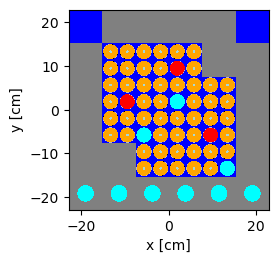

In [8]:
#Graficar la sección transversal del nucleo
plot_args = {
    'width': (6 * bundle_pitch, 6 * bundle_pitch),
    'basis': 'xy',
    'origin': (0.0, 0.0, -40.0),
    'color_by': 'material',
    'colors': {
        water: 'blue',
        uzrh: 'orange',
        graphite: 'gray',
        b4c: 'red',
        air: 'cyan',
        void: 'black',
        ss304: 'silver'
    }
}
bundle_universe.plot(**plot_args)

In [9]:
#Parametros de simulacion

batches = 250
inactive = 50
particles = 50000

settings_file = openmc.Settings()
settings_file.batches = batches
settings_file.inactive = inactive
settings_file.particles = particles

#Limites
bounds = [-24.0, -24.0, -98.0, 24.0, 24.0, -16.0]
uniform_dist = openmc.stats.Box(bounds[:3], bounds[3:])

#Fuente
source = openmc.IndependentSource(space=uniform_dist)
source.constraints = {'fissionable': True}
settings_file.source = source

#Malla - Entropia
entropy_mesh = openmc.RegularMesh()
entropy_mesh.lower_left = bounds[:3]
entropy_mesh.upper_right = bounds[3:]
entropy_mesh.dimension = [10, 10, 10]
settings_file.entropy_mesh = entropy_mesh

settings_file.export_to_xml()

In [10]:
# Mallas y tallies

#Malla flujo
mesh = openmc.RegularMesh()
mesh.dimension = [100, 100, 1] 
mesh.lower_left = [-24.0, -24.0, -56.0] 
mesh.upper_right = [24.0, 24.0, -16.0]  

mesh_filter = openmc.MeshFilter(mesh)

flux_map_tally = openmc.Tally(name='flux_map')
flux_map_tally.filters = [mesh_filter]
flux_map_tally.scores = ['flux']

#Malla letargia
energy_bins = np.logspace(-5, np.log10(20e6), 501)
energy_filter = openmc.EnergyFilter(energy_bins)

spectrum_tally = openmc.Tally(name='flux_spectrum')
spectrum_tally.filters = [energy_filter]
spectrum_tally.scores = ['flux']

#Tasas reaccion
rxn_tally = openmc.Tally(name='reaction_rates')
rxn_tally.scores = ['fission', 'absorption', 'scatter']

tallies = openmc.Tallies([flux_map_tally, spectrum_tally, rxn_tally])
tallies.export_to_xml()

In [11]:
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

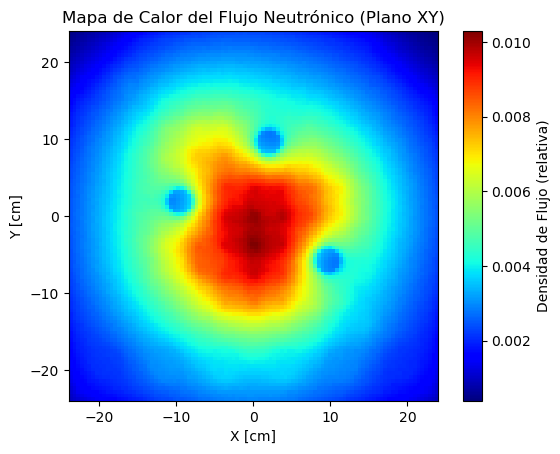

In [12]:
import matplotlib.pyplot as plt

sp = openmc.StatePoint('statepoint.250.h5')
flux_tally = sp.get_tally(name='flux_map')

flux_mean = flux_tally.get_values(value='mean').reshape((100, 100))

#Generar el mapa de calor
plt.imshow(flux_mean, origin='lower', extent=[-24, 24, -24, 24], cmap='jet')
plt.colorbar(label='Densidad de Flujo (relativa)')
plt.title('Mapa de Calor del Flujo Neutrónico (Plano XY)')
plt.xlabel('X [cm]')
plt.ylabel('Y [cm]')
plt.show()

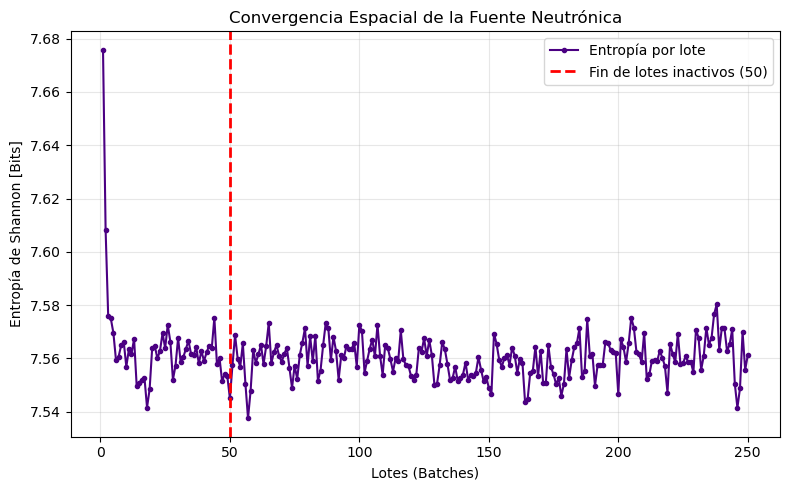

In [13]:
#Grafica entropia

sp = openmc.StatePoint('statepoint.250.h5')

entropy = sp.entropy
batches = range(1, len(entropy) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(batches, entropy, marker='o', markersize=3, linestyle='-', color='indigo', label='Entropía por lote')

ax.axvline(x=50, color='red', linestyle='--', linewidth=2, label='Fin de lotes inactivos (50)')

ax.set_xlabel('Lotes (Batches)')
ax.set_ylabel('Entropía de Shannon [Bits]')
ax.set_title('Convergencia Espacial de la Fuente Neutrónica')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

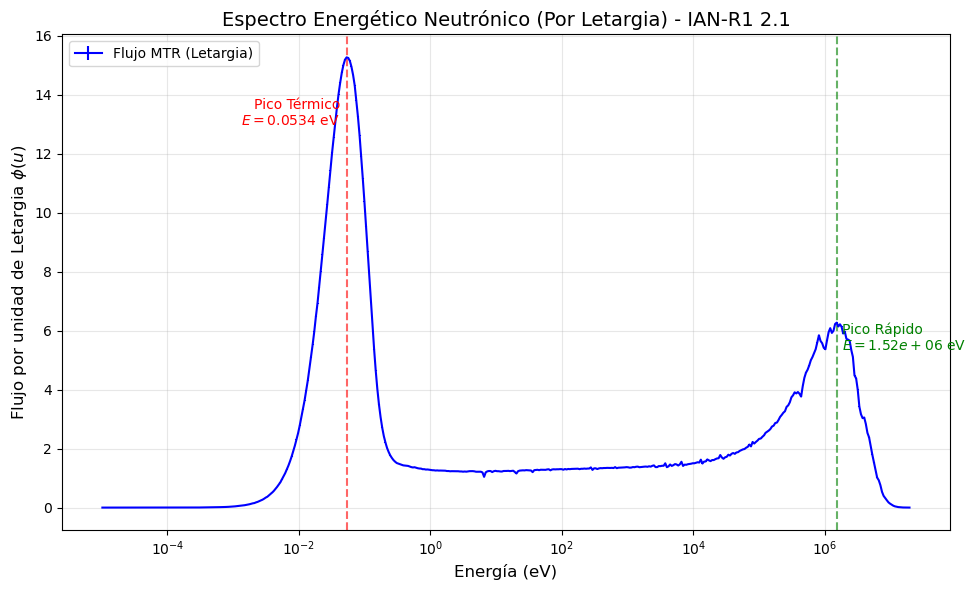

In [14]:
#Grafica letargia

sp = openmc.StatePoint('statepoint.250.h5')
spectrum_tally = sp.get_tally(name='flux_spectrum')

flux = spectrum_tally.get_values(value='mean').flatten()
flux_unc = spectrum_tally.get_values(value='std_dev').flatten()

energy_bounds = spectrum_tally.filters[0].bins
energy_centers = 0.5 * (energy_bounds[:, 0] + energy_bounds[:, 1])
lethargy_widths = np.log(energy_bounds[:, 1] / energy_bounds[:, 0])

flux_lethargy = flux / lethargy_widths
flux_unc_lethargy = flux_unc / lethargy_widths

thermal_mask = energy_centers < 1.0
E_thermal_region = energy_centers[thermal_mask]
flux_thermal_region = flux_lethargy[thermal_mask]

idx_max_thermal = np.argmax(flux_thermal_region)
E_peak_thermal = E_thermal_region[idx_max_thermal]
val_peak_thermal = flux_thermal_region[idx_max_thermal]

fast_mask = energy_centers > 1e5
E_fast_region = energy_centers[fast_mask]
flux_fast_region = flux_lethargy[fast_mask]

idx_max_fast = np.argmax(flux_fast_region)
E_peak_fast = E_fast_region[idx_max_fast]
val_peak_fast = flux_fast_region[idx_max_fast]

fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.errorbar(energy_centers, flux_lethargy, yerr=flux_unc_lethargy, 
             fmt='-', color='b', linewidth=1.5, label='Flujo MTR (Letargia)')

ax1.set_xscale('log')
ax1.set_xlabel('Energía (eV)', fontsize=12)
ax1.set_ylabel(r'Flujo por unidad de Letargia $\phi(u)$', fontsize=12)
ax1.set_title('Espectro Energético Neutrónico (Por Letargia) - IAN-R1 2.1', fontsize=14)

ax1.axvline(x=E_peak_thermal, color='red', linestyle='--', alpha=0.6)
ax1.text(E_peak_thermal * 0.8, val_peak_thermal * 0.85, 
         f'Pico Térmico\n$E = {E_peak_thermal:.4f}$ eV', color='red', ha='right')

ax1.axvline(x=E_peak_fast, color='green', linestyle='--', alpha=0.6)
ax1.text(E_peak_fast * 1.2, val_peak_fast * 0.85, 
         f'Pico Rápido\n$E = {E_peak_fast:.2e}$ eV', color='green', ha='left')

ax1.grid(True, which="both", ls="-", alpha=0.3)
ax1.legend()
plt.tight_layout()
